In [1]:
# Affiche tous les résultats d'une cellule, et pas uniquement le dernier
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# TP 9 : Prise en main de NetworkX et calcul d'itinéraire
L'objectif de ce TP est de prendre en main la bibliothèque Python NetworkX, puis d'implémenter l'algorithme de Dijkstra vu en cours, dans le but de l'appliquer sur un problème concret : calculer le meilleur itinéraire entre deux points d'une ville, et l'afficher sur une carte.

 ## **Première partie : découverte de NetworkX**
[NetworkX](https://networkx.org/) est une bibliothèque Python dédiée à l'études des graphes et des réseaux. La documentation officielle est disponible [ici](https://networkx.org/documentation/stable/tutorial.html).

On commence par installer les différents modules dont nous aurons besoin dans la suite du TP :

In [4]:
%pip install numpy
%pip install matplotlib
%pip install scipy
%pip install networkx

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Puis on importe ces différents modules

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx

  ### **Créer un graphe**

Il existe plusieurs méthodes pour créer un graphe. La plus simple est de créer un graphe vide :

In [3]:
G = nx.Graph() # ou Digraph() pour un graphe orienté

On peut aussi fournir au constructeur une liste d'arêtes / arcs :

In [6]:
edgelist = [(0, 1), (1, 2), (2, 3)]
G = nx.Graph(edgelist)

Il peut être plus pratique de fournir une matrice :

In [7]:
import numpy as np
adjacency_matrix = np.array([[0, 1, 1, 0], [1, 0, 0, 1], [1, 0, 0, 0], [1, 1, 0, 0]])
adjacency_matrix
G = nx.Graph(adjacency_matrix, nodetype=int)
G.edges()

EdgeView([(0, 1), (0, 2), (0, 3), (1, 3)])

NetworkX dispose aussi de nombreux graphes "prêts à l'emploi" ou [générateurs](https://networkx.org/documentation/stable/reference/generators.html) :

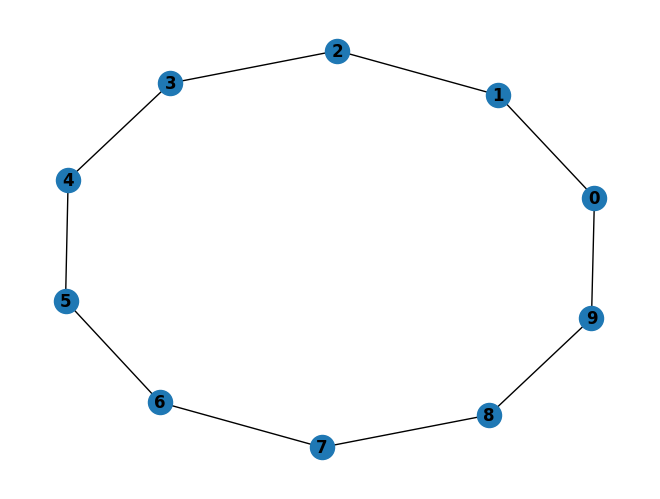

In [5]:
G = nx.cycle_graph(10)
nx.draw(G, with_labels=True, font_weight='bold')

Enfin, on peut aussi créer un graphe à partir d'un autre graphe en utilisant l'une des deux méthodes suivantes :

In [8]:
H = nx.Graph(G)
H = G.copy()

Il est bien sûr possible de construire un graphe à partir d'un fichier, qui contient par exemple les listes d'adjacences des sommets.

In [9]:
%%writefile adjacency_list.dat
0 1 2 3 
1 3 5
3 4

Writing adjacency_list.dat


In [10]:
G = nx.read_adjlist('adjacency_list.dat', nodetype=int)
G.edges

EdgeView([(0, 1), (0, 2), (0, 3), (1, 3), (1, 5), (3, 4)])

### **Afficher un graphe**

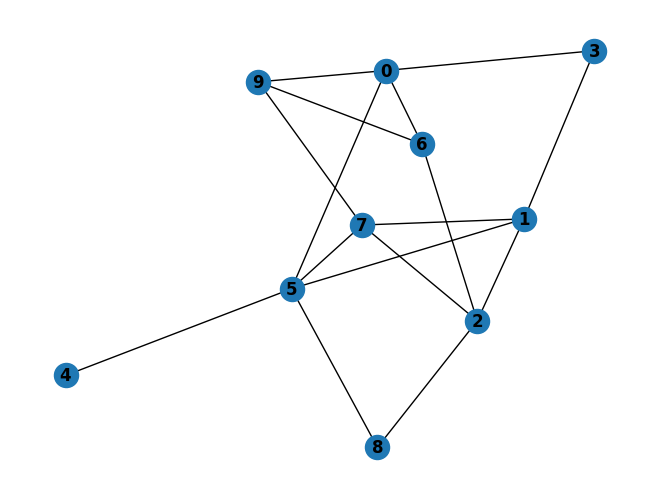

In [11]:
G = nx.gnp_random_graph(10, 0.4)
nx.draw(G, with_labels=True, font_weight='bold')

Par défaut, la position des sommets est aléatoire et change à chaque exécution. Si on demande de dessiner le même graphe une seconde fois, le résultat sera différent :

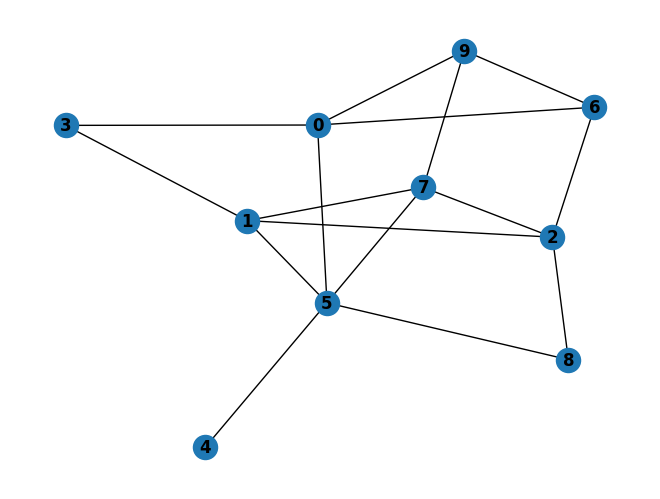

In [12]:
nx.draw(G, with_labels=True, font_weight='bold')

Il est cependant possible de spécifier explicitement les positions des noeuds, grâce aux fonctions `*_layout`. Par exemple, la fonction `random_layout` renvoie les positions aléatoires des noeuds, qu'on peut stocker pour redessiner exactement le même graphe :

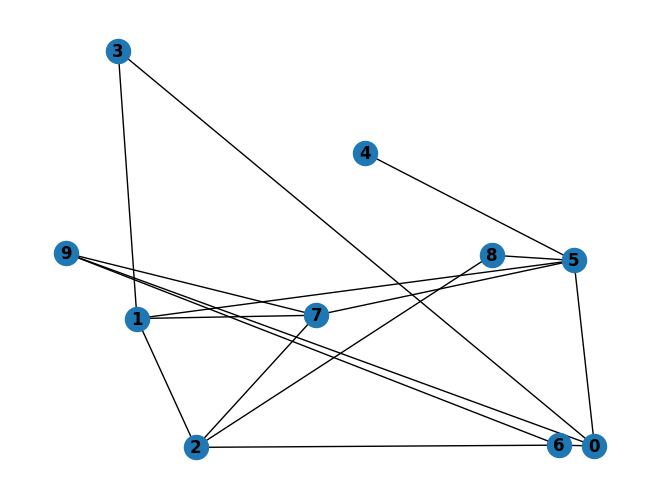

In [13]:
pos = nx.random_layout(G)
pos
nx.draw(G, pos=pos, with_labels=True, font_weight='bold')

En fournissant les positions, un second appel à `draw` affichera donc exactement le même graphe :

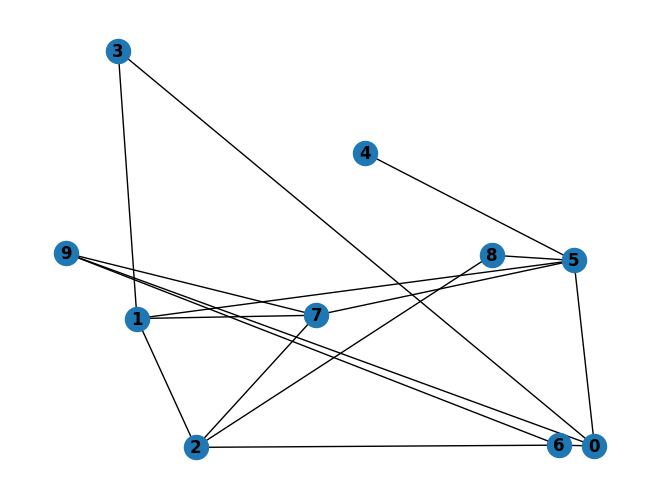

In [14]:
nx.draw(G, pos=pos, with_labels=True, font_weight='bold')

NetworkX dispose de plusieurs dispositions (ou *layouts*) prédéfinies. On peut par exemple demander une disposition des sommets circulaire :

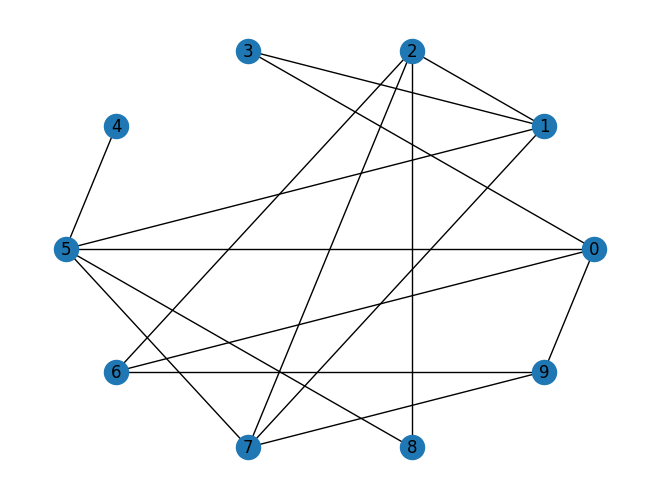

In [15]:
nx.draw_circular(G, with_labels=True)

Comme le montre l'exemple suivant, les possibilités sont infinies !

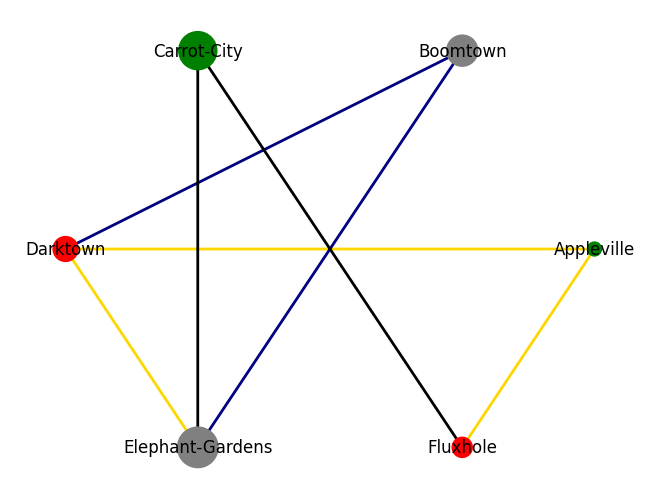

In [16]:
G = nx.MultiGraph()
G.add_nodes_from([('A', {'pop':1000, 'lifeq':'+'}), ('B', {'pop':5000, 'lifeq':'o'}),\
                  ('C', {'pop': 7500, 'lifeq':'+'}), ('D', {'pop': 3200, 'lifeq':'-'}),\
                 ('E', {'pop': 8500, 'lifeq':'o'}), ('F', {'pop':2100, 'lifeq':'-'})])

G.add_edges_from([ ('A', 'D', {'speed':'fast'}),
                   ('E', 'D', {'speed':'fast'}),
                   ('F', 'C', {'speed':'slow'}),
                  ('E', 'C', {'speed':'slow'}),
                 ('B', 'D', {'speed':'medium'}),
                 ('E', 'B', {'speed':'medium'}),
                 ('A', 'F', {'speed':'fast'})])

names = {'A': 'Appleville', 'B':'Boomtown', 'C':'Carrot-City', 'D':'Darktown', 'E':'Elephant-Gardens', 'F':'Fluxhole'}

# node size
population = [nx.get_node_attributes(G, 'pop')[node]/10. for node in G]

# node color
color_of_quality = {'+': 'green', '-':'red', 'o':'grey'}
quality_colors = [color_of_quality[nx.get_node_attributes(G, 'lifeq')[node]] for node in G]

# edge color
color_of_transport={'slow':'black', 'medium':'navy', 'fast':'gold'}
transport_colors = [color_of_transport[prop['speed']] for u, v, prop in G.edges(data=True)]

nx.draw_circular(G, \
                 node_size=population, \
                 node_color=quality_colors, \
                 edge_color=transport_colors, \
                 width=2, \
                 with_labels=True, \
                 labels=names)

💡 Il est conseillé de visiter le site de la principale bibliothèque Python de visualisation de données, [Matplotlib](https://matplotlib.org/).

### **Ajouter des sommets ou des arêtes / arcs**

In [17]:
G = nx.DiGraph()
G.add_nodes_from(range(5))
G.add_edges_from([(0,1),(3,4),(4,2),(1,3),(4,0),(1,2)])

💡 NetworkX se contente d'ignorer les sommets ou arêtes / arcs qui seraient éventuellement déjà présents dans le graphe.

💡 Les identifiants de sommets ne sont pas limités à des nombres : NetworkX accepte n'importe quelle donnée *hachable* (c'est-à-dire à partir de laquelle on peut calculer un identifiant), comme une chaîne de caractère, une image, un fichier XML... :

In [18]:
G = nx.Graph()
G.add_node("sommet 1")    # ajoute le sommet "sommet 1"
G.add_nodes_from("abcdef")  # adds 6 sommets: 'a', 'b', 'c', 'd', 'e', 'f'
G.add_edge(0, 'z')

### **Supprimer des sommets ou des arêtes / arcs**

In [19]:
G.remove_node('c')
G.remove_nodes_from("abcd")
G.remove_edge(0, 'z')

### **Obtenir des renseignements sur un graphe**
NetworkX dispose de nombreuses fonctions permettant d'obtenir des renseignements sur un graphe, notamment :
-   `g.degree()`  : degrés des sommets du graphe g
-   `g.number_of_nodes()`  : nombre de sommets du graphe g
-   `g.number_of_edges()`  : nombre d’arcs du graphe g
-   `g.predecessors(i)`  : liste des prédécesseurs du sommet i
-   `g.successors(i)`  : liste des successeurs du sommet i
-   `g.neighbors(i)`  : liste des voisins du sommet i

⚠️ Pour un graphe orienté, `DiGraph.neighbors` est un synonyme de `DiGraph.successors`.

In [20]:
G = nx.DiGraph()
G.add_nodes_from(range(5))
G.add_edges_from([(0,1),(3,4),(4,2),(1,3),(4,0),(1,2)])
print(f"Nombre de sommets : {G.number_of_nodes()}")
print(f"Liste des sommets : {list(G.nodes)}")

print(f"Nombre d'arcs : {G.number_of_edges()}")
print(f"Liste des arcs : {list(G.edges)}")

print(f"Le sommet 1 est de degré : {G.degree[1]}")

print(f"Les successeurs du sommet 4 sont : {list(G.successors(4))}")

print(f"Les prédesseurcs du sommet 3 sont : {list(G.predecessors(3))}")

print(f"Les voisins du sommet 1 sont : {list(G.neighbors(1))}") # ou list(G.adj[1])

Nombre de sommets : 5
Liste des sommets : [0, 1, 2, 3, 4]
Nombre d'arcs : 6
Liste des arcs : [(0, 1), (1, 3), (1, 2), (3, 4), (4, 2), (4, 0)]
Le sommet 1 est de degré : 3
Les successeurs du sommet 4 sont : [2, 0]
Les prédesseurcs du sommet 3 sont : [1]
Les voisins du sommet 1 sont : [3, 2]


### **Matrices**
NetworkX permet d'obtenir directement la matrice d'adjacence ou d'incidence d'un graphe :

In [23]:
nx.adjacency_matrix(G).todense()
nx.incidence_matrix(G).todense()

array([[1., 0., 0., 0., 0., 1.],
       [1., 1., 1., 0., 0., 0.],
       [0., 0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 0.],
       [0., 0., 0., 1., 1., 1.]])

Il sera parfois plus commode de manipuler une autre représentation, basée sur des dictionnaires (ce qui correspond plus ou moins à une liste d'adjacence) :

In [24]:
nx.to_dict_of_dicts(G)

{0: {1: {}}, 1: {3: {}, 2: {}}, 2: {}, 3: {4: {}}, 4: {2: {}, 0: {}}}

### **Exercice 1**

Dans la suite, vous aurez besoin des packages `networkx`, `matplotlib` et `scipy`. Installez-les à l'aide de la commande `pip install *package*` (dans un terminal) si vous ne les avez pas sur votre machine.

Q1 : Créez le graphe de Petersen en donnant explicitement la liste de ses arêtes

In [2]:
import networkx as nx
G = nx.MultiGraph()
G.add_nodes_from([('0'), ('1'),\
                  ('2'), ('3'),\
                 ('4'), ('5'),('6'),('7'),('8'),('9')])

G.add_edges_from([ ('0', '1'),
                   ('0', '4'),
                   ('0', '5'),
                  ('5', '7'),
                  ('5', '8'),
                  ('6', '1'),
                  ('6', '9'),
                  ('6', '8'),
                  ('7', '9'),
                  ('7', '2'),
                  ('8', '3'),
                  ('4', '9'),
                 ('2', '7'),
                 ('2', '1'),
                 ('2', '3'),
                 ('3', '4'),])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

Q2 : Affichez le graphe créé, en indiquant les numéros de sommets en gras

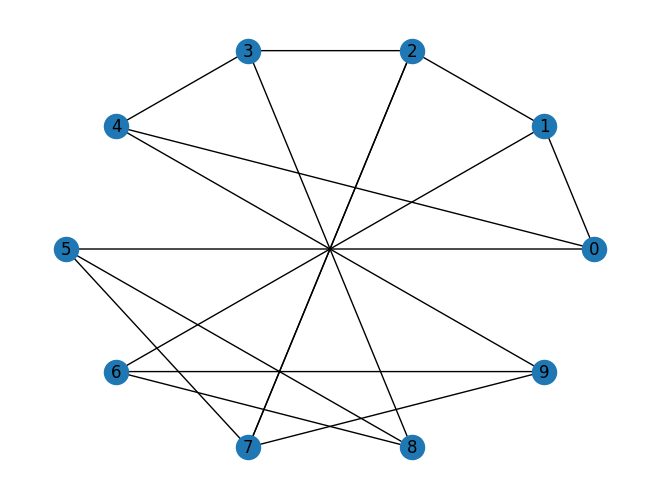

In [4]:
nx.draw_circular(G,
                 with_labels=True)

Par défaut, les sommets sont disposés de manière aléatoire, ce qui ne facilite pas la lecture des graphes ayant une structure régulière, comme le graphe de Petersen. Cherchez dans la documentation de NetworkX une autre fonction permettant d'afficher ce graphe sous sa forme plus "habituelle" (un pentagone croisé inscrit dans un pentagone, cf. TD précédent)

In [5]:
nx.planar_layout(G);

NetworkXException: G is not planar.

Pour les questions qui suivent, donnez la réponse **en utilisant les fonctions de NetworkX**

Ce graphe est-il orienté ou non orienté ?

Quels sont ses sommets et ses arêtes ?

Quels sont les voisins du sommet 2 ? Quel est le degré du sommet 9 ?

Ce graphe est-il régulier ?

Ce graphe est-il connexe ?

Donnez sa matrice d’incidence et sa matrice d’adjacence

Quel est le sous-graphe induit par les sommets {6, 3, 7, 8, 1, 5} ?

Mettez en évidence (avec des arêtes rouges) un chemin hamiltonien (calculé à la main) sur le graphe de Petersen

*(Facultatif pour les IRC)* Quelle est la taille d'un transversal minimum ? D'un couplage maximum ? D'un stable maximum ? D'une coloration minimum ?

## **Deuxième partie : réalisation d'un calculateur d'itinéraire**

L'objectif de cet exercice est de réaliser un calculateur d'itinéraire, basé sur votre propre implémentation de l'**algorithme de Dijkstra** (donc **sans** faire appel aux fonctions de la famille `shortest_path` ou `dijkstra_path` de NetworkX), et d'observer comment le choix d'une *bonne* structure de données affecte les performances de l'algorithme.

### **Exercice 2**
#### **Question 1**

A l'aide de la fonction `read_multiline_adjlist`, chargez et affichez le graphe fourni dans le fichier `TP8_Ex2_graphe.txt`

:warning: Dans ce fichier, les noms des sommets sont des **entiers**

Remarque : voici le code qui a permis de générer ce graphe :

```python
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1,figsize=(10,8)) 
G = nx.gnm_random_graph(20, 30)
for (u, v) in G.edges():
    G.edges[u,v]['length'] = random.randint(1,50)

pos=nx.circular_layout(G)
nx.draw_networkx(G,pos, with_labels = True, font_color='w',font_weight='bold')
labels = nx.get_edge_attributes(G,'length')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels,font_size=8,alpha=0.5,font_weight='bold');  # ';' pour masquer le dictionnaire retourné

nx.write_multiline_adjlist(G, "TP8_Ex2_graphe.txt")
```

:warning: Assurez-vous d'avoir obtenu un graphe *connexe* ; si ce n'est pas le cas, relancez la cellule précédente jusqu'à obtenir un graphe connexe.

#### **Question 2**
Implémentez l'algorithme de Dijkstra tel qu'il a été présenté dans le cours, de sorte à calculer un plus court chemin entre deux sommets. Votre fonction, nommée `dijkstra1`, prendra donc en paramètres
* un graphe pondéré `G`
* un sommet de départ `s`
* un sommet de destination `d`

et retournera un **tuple** constitué de :
* la longueur du plus court chemin de `s` à `d` trouvé
* l'itinéraire de `s` à `s`, sous forme de liste.

:bulb: Dans un premier temps, bien que ce ne soit pas optimal, vous conserverez la trace des sommets déjà visités dans une ***liste*** Python. 

Appliquez votre fonction au graphe précédent, pour calculer le plus court chemin du sommet 0 au sommet 19 ; vous devriez trouver le chemin 0 - 17 - 1 - 3 - 9 - 19, d'une longueur de 80.

:bulb: L'utilisation d'une *liste* pour gérer les sommets déjà visités est clairement contre-productive : à chaque itération, on doit vérifier si les voisins du sommet courant n'ont pas déjà été visités. Or l'instruction `in` appliquée à une liste consiste à parcourir séquentiellement les éléments jusqu'à tomber sur celui que l'on cherche (ou atteindre la fin de la liste) ; autrement dit, cette opération est en *O*(n). Et comme on être amené à effectuer *O*(n) itérations, on se retrouve avec un algorithme de complexité *O*(n²)... Ca ne change pas grand chose sur un graphe de 10 sommets, mais sur des graphes de plusieurs milliers de sommets et arêtes comme vous allez en manipuler dans la suite, la différence est sensible !

Il faudrait donc remplacer l'utilisation de cette liste par un type de données permettant de savoir *rapidement* (i.e. en *O*(1)) si elle contient un élément donné ou non.

#### **Question 3**
Proposez une solution remplaçant avantageusement la liste, dans une version modifiée de votre fonction `dijkstra` que vous nommerez `dijkstraV2`

Vérifiez que votre fonction renvoie bien le chemin attendu entre 0 et 19 sur le graphe précédent.

### **Exercice 3 : Application au calcul d'itinéraire**
[OSMnx](https://geoffboeing.com/2016/11/osmnx-python-street-networks/) est un package Python permettant d'exploiter au format NetworkX les données géographiques disponibles sur [OpenStreetMap](https://openstreetmap.org). Il permet notamment de récupérer toutes les informations du réseau routier, piéton, de transports en commun, etc. et de les manipuler avec NetworkX. De nombreux exemples sont disponibles [sur cette page](https://github.com/gboeing/osmnx-examples).

On commence donc par installer `osmnx` :

In [ ]:
%pip install osmnx

On importe ensuite les paquets nécessaires :

In [45]:
import osmnx as ox

# Permet d'obtenir les figures directement dans le notebook
%matplotlib inline

#### **Question 1**
Chargez puis affichez le réseau routier de Lyon (cela peut prendre plusieurs secondes) :

Par défaut, les sommets sont affichés ; quand ils sont trop nombreux, ils nuisent à la lisibilité du graphe. Affichez de nouveau le réseau routier, en jaune, dans une image de taille 10x10, et sans afficher les sommets.

Combien de sommets et d'arêtes ce graphes comporte-t-il ?

#### **Question 2**

A l'aide de la fonction `get_edge_data()`, affichez l'ensemble des attributs de la première arête du graphe

Il serait plus pratique d'avoir ces informations directement sur une carte... Heureusement, c'est tout-à-fait possible !
Il vous faut tout d'abord convertir votre graphe en *GeoDataFrame* (il existe une fonction OSMnx pour ça ;), puis (en fouillant un peu dans la documentation de [GeoDataFrame](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html)) appliquer la fonction qui permet d'obtenir une carte interactive.

#### **Question 3**

Les numéros des sommets donnés par OpenStreetMap sont ceux de sa base de données *mondiale*, et ne sont donc pas très pratiques si on veut gérer des tableaux de sommets et repérer ces derniers par leur index (les numéros peuvent être très grands, et surtout il y a de nombreux "trous" dans la numérotation). Commencez par *réétiqueter* les sommets, de sortes qu'ils soient numérotés `0, 1, 2...` (il existe, bien sûr, une fonction de NetworkX permettant de faire ceci...)

A présent, récupérez (par exemple *via* Google Maps, ou [OpenStreetMap](https://www.openstreetmap.org) en faisant un clic-droit puis *Affichez l'adresse*) les coordonnées géographiques (latitude et longitude) correspondant aux deux adresses suivantes :
* Point de Départ : 6 Rue Plasson et Chaize
* Point d'Arrivée : 21 Rue Thénard

Une fois les coordonnées géographiques obtenues, on utilise la fonction OSMNx `nearest_nodes` pour obtenir les sommets / noeuds du graphe les plus proches. Utilisez cette fonction pour récupérer les identifiants des points de départ et d'arrivée

#### **Question 4**

Si vous avez été attentif aux données retournées par la fonction `get_edge_data()` à la fin de la question 2, vous avez pu constater que les données des arêtes du graphe routier sont renvoyées sous forme d'un **dictionnaire**, et sont accessibles en utilisant la clé `0`. Il faut donc légèrement modifier les fonctions `dijkstra` et `dijkstraV2` pour prendre en compte cette subtilité

Fonction `dijkstra` modifiée :

Fonction `dijkstraV2` modifiée :

Appliquez les fonctions `dijkstra` et `dijkstraV2` afin de déterminer l'itinéraire le plus court entre les deux sommets donnés plus haut. A l'aide du module `time` déjà utilisé en TP, comparez leur temps d'exécution.

Si vous êtes arrivé jusqu'ici, vous avez un calculateur d'itinéraire opérationnel ! Il ne vous reste plus qu'à visualiser votre travail. A l'aide de la fonction `plot_graph_route`, superposez le graphe et l'itinéraire obtenu :